### Imports and load the data

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

In [4]:
ROOT = Path("..")
PROCESSED_DIR = ROOT / "data" / "processed"

df = pd.read_csv(PROCESSED_DIR / "modeling_dataset.csv")

df["week"] = pd.to_datetime(df["week"])

df.head()

,state,week,total_respiratory_admissions,aqi_mean,aqi_p90,aqi_max,days_reported,year,month,week_of_year,quarter,aqi_mean_lag1,aqi_mean_lag2,aqi_max_lag1,aqi_max_lag2,aqi_p90_lag1,aqi_p90_lag2,aqi_mean_rolling_3
0,AK,2021-01-16,59.71,36.651163,75.8,163,43,2021,1,2,1,44.414634,74.692308,174.0,189.0,116.0,156.8,51.919368
1,AK,2021-01-23,46.43,38.000000,87.0,116,41,2021,1,3,1,36.651163,44.414634,163.0,174.0,75.8,116.0,39.688599
2,AK,2021-01-30,41.57,45.975610,86.0,163,41,2021,1,4,1,38.000000,36.651163,116.0,163.0,87.0,75.8,40.208924
3,AK,2021-02-06,39.86,38.045455,64.4,93,44,2021,2,5,1,45.975610,38.000000,163.0,116.0,86.0,87.0,40.673688
4,AK,2021-02-13,33.43,46.475000,69.3,131,40,2021,2,6,1,38.045455,45.975610,93.0,163.0,64.4,86.0,43.498688


### Define the features and target

In [6]:
target = "total_respiratory_admissions"

features = [
    "aqi_mean", "aqi_p90", "aqi_max", "days_reported",
    "year", "month", "week_of_year", "quarter",
    "aqi_mean_lag1", "aqi_mean_lag2",
    "aqi_max_lag1", "aqi_max_lag2",
    "aqi_p90_lag1", "aqi_p90_lag2",
    "aqi_mean_rolling_3"
]

In [7]:
X = df[features]
y = df[target]

### Train/Test Split (TIME BASED)

In [9]:
split_date = df["week"].quantile(0.8)

train_df = df[df["week"] <= split_date]
test_df = df[df["week"] > split_date]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (10384, 15)
Test size: (2590, 15)


### Linear Regression (baseline model)

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

### Evaluate Linear Regression

In [13]:
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name} Performance:")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.3f}")
    print("-" * 30)

evaluate_model(y_test, y_pred_lr, "Linear Regression")

Linear Regression Performance:
MAE:  622.13
RMSE: 769.44
R²:   -0.878
------------------------------


### Random Forest (main model)

In [15]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### Evaluate Random Forest

In [17]:
evaluate_model(y_test, y_pred_rf, "Random Forest")

Random Forest Performance:
MAE:  173.01
RMSE: 359.62
R²:   0.590
------------------------------


### Compare the models

In [19]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,622.129531,769.436527,-0.877529
1,Random Forest,173.008725,359.616027,0.589872


### Feature Importance

In [21]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
3,days_reported,0.357098
6,week_of_year,0.216885
4,year,0.187153
5,month,0.043904
14,aqi_mean_rolling_3,0.038381
11,aqi_max_lag2,0.026715
10,aqi_max_lag1,0.020381
2,aqi_max,0.020196
9,aqi_mean_lag2,0.017696
8,aqi_mean_lag1,0.016111


### Plot feature importance

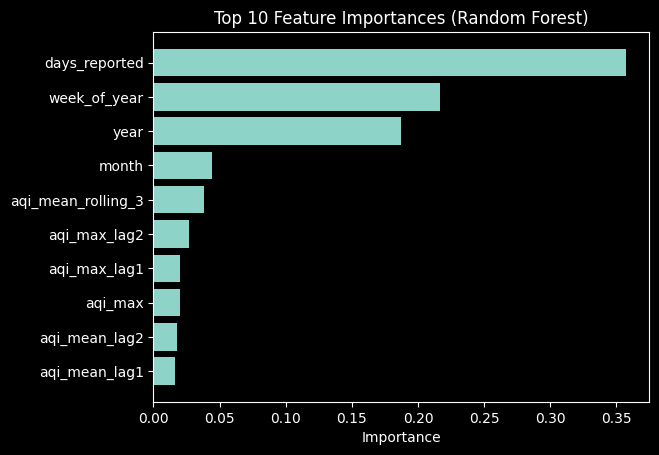

In [23]:
plt.figure()
plt.barh(feature_importance["feature"][:10], feature_importance["importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()

### Predictions vs Actual (this will be used for the dashboard)

In [25]:
pred_df = test_df.copy()

pred_df["pred_lr"] = y_pred_lr
pred_df["pred_rf"] = y_pred_rf

pred_df.head()

,state,week,total_respiratory_admissions,aqi_mean,aqi_p90,aqi_max,days_reported,year,month,week_of_year,quarter,aqi_mean_lag1,aqi_mean_lag2,aqi_max_lag1,aqi_max_lag2,aqi_p90_lag1,aqi_p90_lag2,aqi_mean_rolling_3,pred_lr,pred_rf
196,AK,2024-10-19,6.0,25.487805,51.0,82,41,2024,10,42,4,22.772727,29.268293,66.0,62.0,45.5,53.0,25.842942,-426.443860,26.685082
197,AK,2024-10-26,17.0,27.658537,39.0,68,41,2024,10,43,4,25.487805,22.772727,82.0,66.0,51.0,45.5,25.306356,-417.228110,27.998605
198,AK,2024-11-02,17.0,30.090909,51.2,60,44,2024,11,44,4,27.658537,25.487805,68.0,82.0,39.0,51.0,27.745750,-531.212265,38.696351
199,AK,2024-11-09,39.0,28.200000,54.2,77,40,2024,11,45,4,30.090909,27.658537,60.0,68.0,51.2,39.0,28.649815,-564.429907,59.981799
200,AK,2024-11-16,34.0,39.628571,74.8,90,35,2024,11,46,4,28.200000,30.090909,77.0,60.0,54.2,51.2,32.639827,-583.161739,73.344014


### Save the outputs

In [27]:
pred_df.to_csv(PROCESSED_DIR / "model_predictions.csv", index=False)
feature_importance.to_csv(PROCESSED_DIR / "feature_importance.csv", index=False)

print("Saved prediction outputs.")

Saved prediction outputs.
